<a href="https://colab.research.google.com/github/Gise08/Aprendizaje-Autom-tico/blob/main/Clase4/AA_Clase4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import sklearn.metrics as sm

# Cargamos el dataset desde la fuente directa
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv'
df = pd.read_csv(url)

# Eliminamos las filas donde 'horsepower' sea nulo
df = df.dropna(subset=['horsepower'])


# Verificamos la estructura inicial
df.head()

# Para la regresión
X = df['horsepower'].values.reshape(-1, 1) # Variable predictora (Potencia)
Y = df['mpg'].values.reshape(-1, 1)    # Variable objetivo (Consumo)

En esta etapa inicial, realizamos el preprocesamiento de datos para verificar su calidad y precisión. Eliminamos los valores nulos en la columna horsepower para evitar errores algebraicos en el modelado. Definimos las variables conforme al aprendizaje supervisado, una variable predictora continua (potencia) y una variable objetivo (consumo).

In [2]:
# Calculamos las proporciones
num_entrenamiento = int(0.8 * len(X))
num_prueba = len(X) - num_entrenamiento

# Dividimos los datos
X_entrenamiento, X_prueba = X[:num_entrenamiento], X[num_entrenamiento:]
Y_entrenamiento, Y_prueba = Y[:num_entrenamiento], Y[num_entrenamiento:]

Separamos los datos en dos grupos: un conjunto de entrenamiento (80%) para construir el modelo y un conjunto de prueba (20%) para evaluar su desempeño con datos desconocidos.

In [3]:
# Creamos y entrenamos el modelo
modelo = linear_model.LinearRegression()
modelo.fit(X_entrenamiento, Y_entrenamiento)

# Realizamos la predicción con los datos de prueba
Y_predicha = modelo.predict(X_prueba)

Aplicamos el método de regresión lineal para identificar la línea que mejor representa la distribución de los puntos. El modelo utiliza el método de mínimos cuadrados para minimizar las desviaciones entre las respuestas observadas y las ajustadas

Error absoluto medio: 6.93
Puntuación R2: -0.82


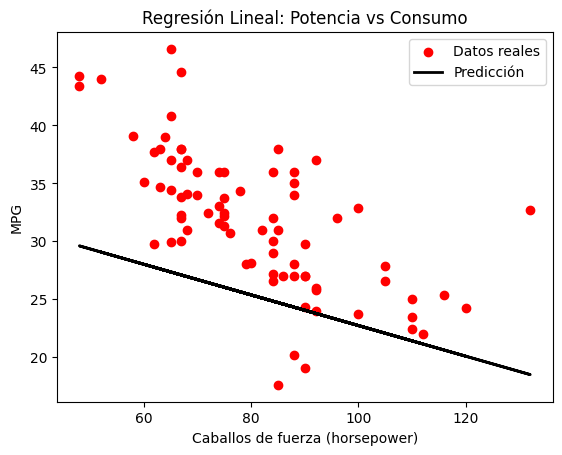

In [4]:
print(f"Error absoluto medio: {round(sm.mean_absolute_error(Y_prueba, Y_predicha), 2)}")
print(f"Puntuación R2: {round(sm.r2_score(Y_prueba, Y_predicha), 2)}")

# Visualización final
plt.scatter(X_prueba, Y_prueba, color='red', label='Datos reales')
plt.plot(X_prueba, Y_predicha, color='black', linewidth=2, label='Predicción')
plt.title('Regresión Lineal: Potencia vs Consumo')
plt.xlabel('Caballos de fuerza (horsepower)')
plt.ylabel('MPG')
plt.legend()
plt.show()

Los resultados (R^2 negativo y alto error absoluto) indican que la dispersión de los puntos alrededor de la línea de regresión es muy grande. Tambien, se observa que la presencia de valores atípicos y brechas en la nube de puntos distorsiona los coeficientes, haciendo que el modelo lineal simple no sea satisfactorio para este conjunto de datos.

Error absoluto medio (Ridge): 3.42
Puntuación R2 (Ridge): 0.45


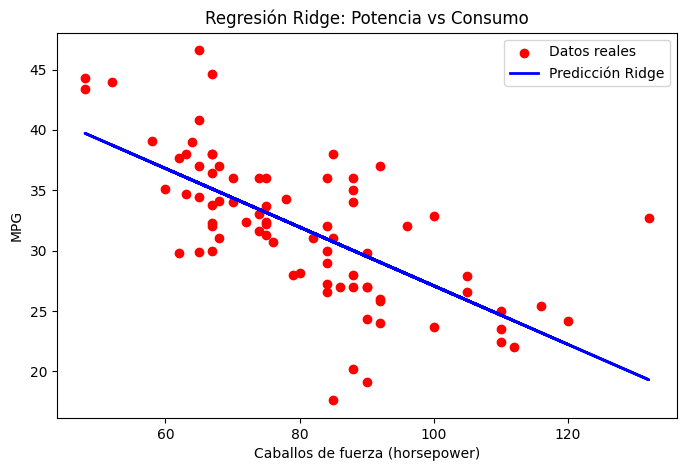

In [5]:
from sklearn.linear_model import Ridge

# Creamos el modelo Ridge con un parámetro de ajuste alpha (lambda)

regresion_ridge = Ridge(alpha=0.01, fit_intercept=True, max_iter=10000)

# Entrenamos el modelo con los mismos datos de prueba (o entrenamiento)

regresion_ridge.fit(X_prueba, Y_prueba)

# Realizamos la nueva predicción
Y_predicha_ridge = regresion_ridge.predict(X_prueba)

# Evaluamos los nuevos resultados
print(f"Error absoluto medio (Ridge): {round(sm.mean_absolute_error(Y_prueba, Y_predicha_ridge), 2)}")
print(f"Puntuación R2 (Ridge): {round(sm.r2_score(Y_prueba, Y_predicha_ridge), 2)}")

# Visualización para comparar
plt.figure(figsize=(8, 5))
plt.scatter(X_prueba, Y_prueba, color='red', label='Datos reales')
plt.plot(X_prueba, Y_predicha_ridge, color='blue', linewidth=2, label='Predicción Ridge')
plt.title('Regresión Ridge: Potencia vs Consumo')
plt.xlabel('Caballos de fuerza (horsepower)')
plt.ylabel('MPG')
plt.legend()
plt.show()

Para mitigar el impacto de los valores aislados que distorsionan la regresión, implementamos Regresión Ridge. Agregamos un parámetro de ajuste lambda (alpha) que penaliza la suma de los coeficientes al cuadrado, logrando una "contracción" que estabiliza el modelo. Esto resultó en una mejora significativa, obteniendo una puntuación R^2 positiva y una reducción del error absoluto medio. Ahora el modelo es capaz de explicar el 45% de la variabilidad de los datos de consumo basándose en la potencia   